In [12]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "unique-spirit-494108-g2"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?

ANSWER: A good agricultural subregion is useful because it has relatively uniform fields, so changes in VV, VH, and VV–VH mainly reflect crop growth cycles rather than mixed land cover effects. Over a year, crops show strong seasonal variation (VV and VH rise during growth and drop after harvest), forests stay relatively stable with consistently high VH, and urban areas remain fairly constant with high VV due to buildings and low seasonal variability.

In [13]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.95, 43.65, -93.25, 44.15])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [14]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?

ANSWER: Advantages: Monthly median stacks reduce speckle noise in SAR data and remove short-term outliers, making the signal cleaner and more representative of typical conditions. They also help highlight long-term, stable land cover changes by smoothing day-to-day variability.

Disadvantages: Temporal averaging can remove important short-lived events and reduce the ability to detect rapid changes. It also blends different surface states within the month, which can hide real variability in the data.

QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?

ANSWER: Filtering by orbit direction, instrument mode, polarization, and resolution ensures that all Sentinel-1 images are comparable and that differences in the time series mainly reflect real surface changes rather than acquisition settings. If ascending and descending passes were mixed, the series would include artificial variability from different viewing geometries, which could create false trends or sudden jumps unrelated to actual change on the ground.

In [15]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")

Monthly images in stack: 10
Month 02: 8 scenes
Month 03: 8 scenes
Month 04: 10 scenes
Month 05: 4 scenes
Month 06: 3 scenes
Month 07: 3 scenes
Month 08: 4 scenes
Month 09: 2 scenes
Month 10: 4 scenes
Month 11: 4 scenes


QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.

ANSWER: In an early season month, both VV and especially VH are low because vegetation is sparse, while in the peak month VH increases much more strongly than VV due to dense plant structure and volume scattering. I would choose agricultural fields, forests, and urban areas as ROIs to compare clear vegetation-driven changes, stable natural cover, and structurally constant built-up backscatter.

In [22]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 7, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.
m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VH"), vh_vis, "VH July")
)
display(m)
#m.addLayer(aoi, {"color": "red"}, "AOI")

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [17]:
#Plot the VV split_map here.

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [28]:
m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [31]:
drawn_fc = m.draw_features
print(drawn_fc)


[<ee.feature.Feature object at 0x0000020F8F821CA0>, <ee.feature.Feature object at 0x0000020F8F822360>, <ee.feature.Feature object at 0x0000020F8F821C10>, <ee.feature.Feature object at 0x0000020F8F822240>, <ee.feature.Feature object at 0x0000020F8F7C0E60>]


In [32]:
# Example fallback polygons
#field_1 = ee.Geometry.Rectangle([-93.731, 43.949, -93.714, 43.964])
#field_2 = ee.Geometry.Rectangle([-93.666, 43.865, -93.646, 43.882])
#control_1 = ee.Geometry.Rectangle([-93.585, 43.971, -93.571, 43.982])  # mixed non-crop / built area
field_1 = drawn_fc[0]
field_2 = drawn_fc[1]
field_3 = drawn_fc[2]
trees_1 = drawn_fc[3]
control_1 = drawn_fc[4]
roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "Trees_1": trees_1,
    "Control_1": control_1
}

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
m

##PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
for name, roi in roi_dict.items():
    print(name, roi.geometry().getInfo())

Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.637285, 43.89527], [-93.637285, 43.89861], [-93.626983, 43.89861], [-93.626983, 43.89527], [-93.637285, 43.89527]]]}
Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.466671, 43.877652], [-93.466671, 43.891695], [-93.446755, 43.891695], [-93.446755, 43.877652], [-93.466671, 43.877652]]]}
Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.668012, 43.811094], [-93.668012, 43.825833], [-93.64758, 43.825833], [-93.64758, 43.811094], [-93.668012, 43.811094]]]}
Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.356761, 43.877454], [-93.356761, 43.883888], [-93.34251, 43.883888], [-93.34251, 43.877454], [-93.356761, 43.877454]]]}
Control_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.366712, 43.674055], [-93.366712, 43.688456], [-93.345938, 43.688456], [-93.345938, 43.674055], [-93.366712, 43.674055]]]}


In [33]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

ts_dict["Field_1"]

,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-30.794876,-18.250217,12.544659,2025-02-01,2,8,2025
1,-21.821355,-13.750866,8.070489,2025-03-01,3,8,2025
2,-23.801429,-15.199491,8.601938,2025-04-01,4,10,2025
3,-23.399131,-15.303668,8.095462,2025-05-01,5,4,2025
4,-20.641747,-14.147837,6.493909,2025-06-01,6,3,2025
5,-18.329757,-12.830598,5.499159,2025-07-01,7,3,2025
6,-18.738425,-12.978779,5.759646,2025-08-01,8,4,2025
7,-19.439823,-13.312376,6.127446,2025-09-01,9,2,2025
8,-20.346386,-13.699771,6.646615,2025-10-01,10,4,2025
9,-23.682724,-15.188317,8.494406,2025-11-01,11,4,2025


QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?

ANSWER: The minimum VH usually occurs in early spring when fields are bare or just starting to grow, while the maximum VH happens in mid-summer during peak vegetation growth. This matches expectations because VH is highly sensitive to vegetation structure, so it increases strongly when crops are fully developed and drops when fields are empty.

QUESTION (20pts):
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

ANSWER:
- Farm areas show the strongest seasonal variability, especially in VH, with clear increases during crop growth and sharp decreases after harvest; forests are more stable with consistently elevated VH due to persistent canopy structure, while towns remain the most stable overall with high VV and weak seasonal changes.
- Crops typically start growing in spring (April–May), reach peak growth in summer, and are harvested in late summer to early autumn (August–October), when VH drops significantly.
- Yes, VV–VH separates crops from other land covers better than VV alone because it enhances vegetation-related contrast by emphasizing the strong VH response in growing crops.
- The urban/town ROI looks least like an actively growing crop field because it shows little seasonal variation and is dominated by stable built structures rather than vegetation dynamics.
- The farm ROI shows the strongest seasonal change in VH (driven by crop growth cycles), while the forest ROI is the most stable through time, consistent with a permanent tree canopy and relatively constant backscatter.

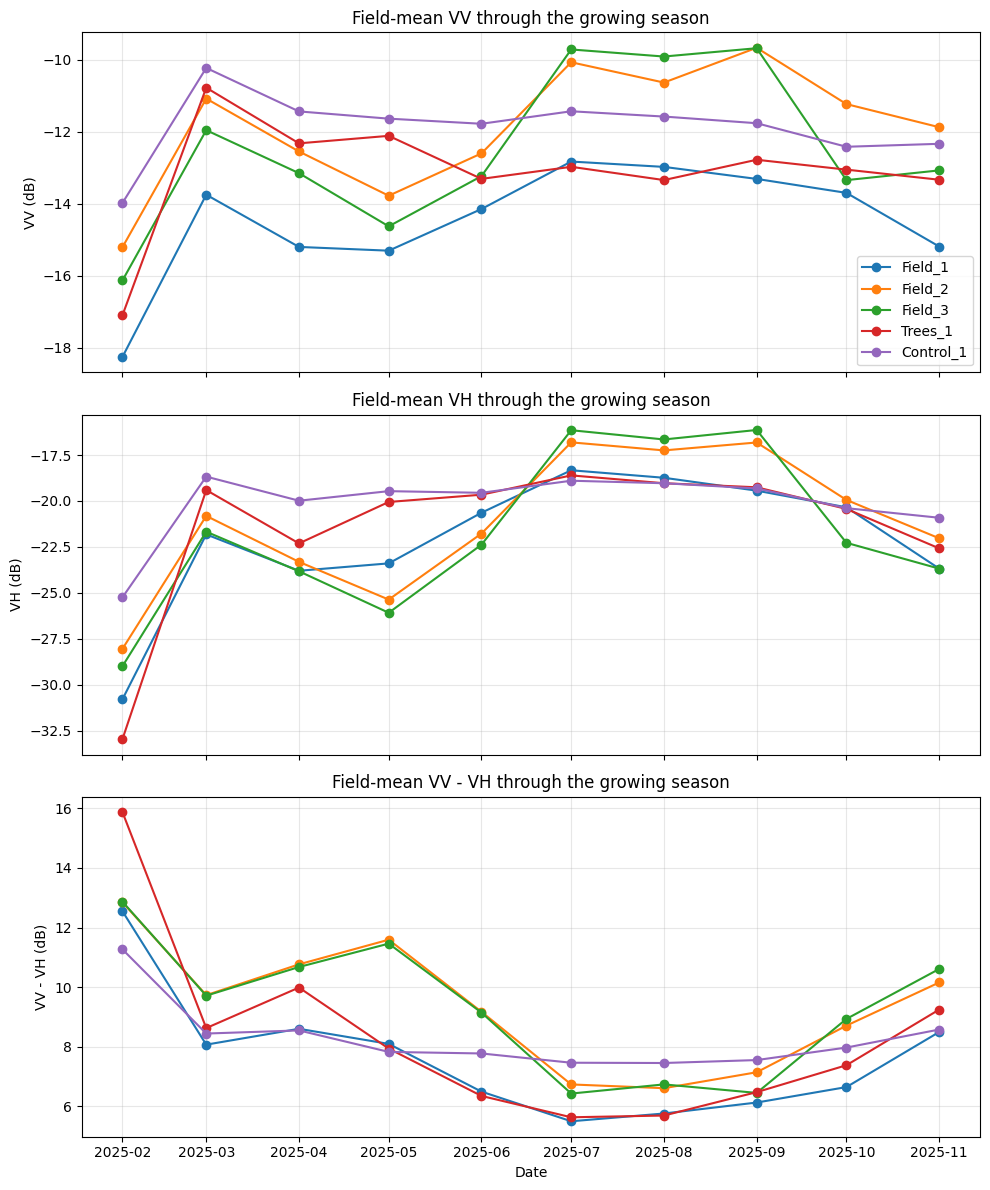

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

 Build a simple crop-growth metric
Next I want you to propose a metric that captures crop development.

Possible first ideas include:

peak VH minus spring VH,
July VH minus April VH,
maximum seasonal VV-VH range,
cumulative increase from planting to peak growth.
Below is one simple example:

[ Growth Metric = VH_{peak} - VH_{early} ]

This is not necessarily the best metric — it is just a starting point.

In [ ]:
##YOUR CODE HERE (50pts)

In [35]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…